In [1]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.model_selection import train_test_split    
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage import feature
import pickle
import os

In [2]:
LIMIT = 1300
IMG_SIZE = (300, 300)
LABELS = np.array(['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro'])
TRAIN_SPLIT_RATIO = 0.8
TEST_SPLIT_RATIO = 0.5

In [3]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for folder_name in LABELS:
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(folder_name)
        print(f"Loaded {len(data)} images from {folder_name}")
    
    return np.array(data), np.array(labels)


In [4]:
dataset, labels = load_images_from_directory('datasets/local_dataset', LIMIT)
print('dataset loaded')

1584 images in Bacterialblight
Loaded 1300 images from Bacterialblight
1440 images in Blast
Loaded 2600 images from Blast
1600 images in Brownspot
Loaded 3900 images from Brownspot
1488 images in Healthy
Loaded 5200 images from Healthy
1318 images in Tungro
Loaded 6500 images from Tungro
dataset loaded


In [5]:
X_train, X_test, y_train, y_test = train_test_split(dataset, labels, train_size=TRAIN_SPLIT_RATIO, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=42)

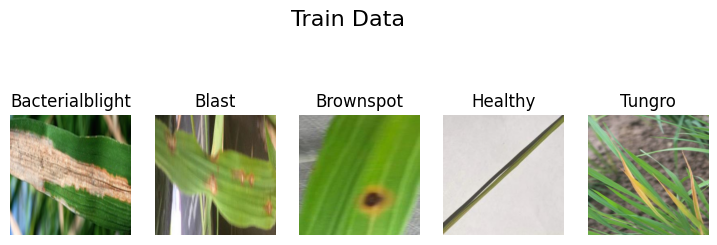

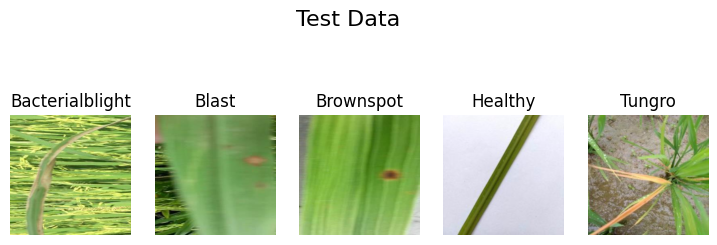

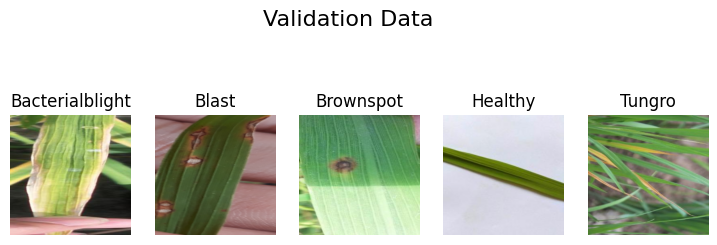

In [6]:
fig = plt.figure(figsize=(9, 6))

fig.suptitle('Train Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(2, len(LABELS), j+1)
    index = np.where(y_train == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_train[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])


fig = plt.figure(figsize=(9, 6))

fig.suptitle('Test Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(2, len(LABELS), j+1)
    index = np.where(y_test == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_test[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])
    
fig = plt.figure(figsize=(9, 6))

fig.suptitle('Validation Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(2, len(LABELS), j+1)
    index = np.where(y_val == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_val[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])

# Pre-Processing


In [7]:
def calculate_color_moments(image):
    moments = []
    
    b, g, r = cv2.split(image)
    for channel in [b, g, r]:
        # print(cv2.moments(channel).values())
        moments.extend(cv2.moments(channel).values())
        # moments.extend([mean, variance])
    return np.array(moments)

In [8]:
def calculate_texture_features_n_hog(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = feature.graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')
    energy = feature.graycoprops(glcm, 'energy')
    homogeneity = feature.graycoprops(glcm, 'homogeneity')
    correlation = feature.graycoprops(glcm, 'correlation')
    dissimilarity = feature.graycoprops(glcm, 'dissimilarity')
    
    # lbp = feature.local_binary_pattern(gray, P=8, R=1, method='uniform')
    hog = feature.hog(gray, pixels_per_cell=(16, 16), cells_per_block=(1, 1), visualize=False, feature_vector=True)
    # return np.concatenate((lbp.flatten(), hog))
    # return hog
    return np.concatenate((hog,contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))

In [9]:
def calculate_histogram(image, channels, mask=None, histSize=[256], ranges=[0, 256]):
    result = []
    for i in range(len(channels)):
        hist = cv2.calcHist([image], [i], mask, histSize, ranges)
        cv2.normalize(hist, hist)
        hist.flatten()
        result.append(hist)
    return np.array(result).flatten()

In [10]:
def extract_features(images):
    features = []
    for img in images:
        color_hist = calculate_histogram(img, channels=[0, 1, 2])
        # color_moments = calculate_color_moments(img)
        hu_moments = cv2.HuMoments(cv2.moments(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))).flatten()
        texture_features_n_hog = calculate_texture_features_n_hog(img)
        # feature_vector = np.concatenate((color_hist, color_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist, color_moments, hu_moments))
        feature_vector = np.concatenate((color_hist, hu_moments, texture_features_n_hog))
        features.append(feature_vector)
    return np.array(features)

In [13]:
feature_img1 = extract_features([X_train[0]])
print(feature_img1.shape)

(1, 3696)


In [14]:
X_train_features = extract_features(X_train)
X_test_features = extract_features(X_test)
X_val_features = extract_features(X_val)

KeyboardInterrupt: 

In [ ]:
scaler = StandardScaler()
x_train_normal = scaler.fit_transform(X_train_features)
x_val_normal = scaler.transform(X_val_features)

In [ ]:
# Train SVM model
svm = SVC(kernel='linear', random_state=42)
# svm.fit(x_train_normal, y_train)
svm.fit(x_train_normal, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
# Make predictions
y_pred = svm.predict(x_val_normal)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy * 100:.4f}%")
precision, recall, fscore, average = precision_recall_fscore_support(y_val, y_pred, average='weighted')
print(f"Precission: {precision * 100:.4f}%")
print(f"Recall: {recall * 100:.4f}%")
print(f"F1: {fscore * 100:.4f}%")

Accuracy: 99.2308%
Precission: 99.2309%
Recall: 99.2308%
F1: 99.2290%


In [ ]:
print(y_val[0], y_pred[0])

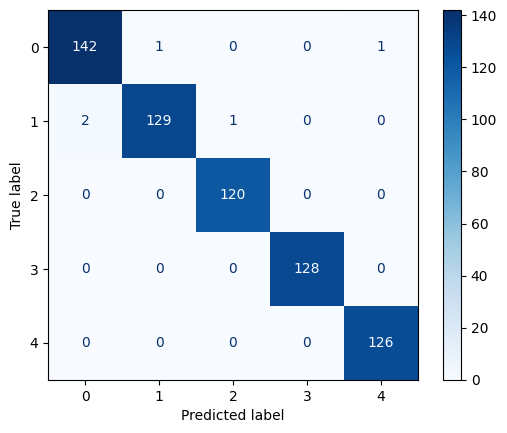

In [ ]:
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
# Save the model to disk
with open(os.path.join(f"E:/Backup Mario/Coding Room/Rice_Disease", 'svm_1.pkl'), 'wb') as file:
    pickle.dump(svm, file)
    
with open(os.path.join(f"E:/Backup Mario/Coding Room/Rice_Disease", 'scaler_1.pkl'), 'wb') as file:
    pickle.dump(scaler, file)

In [ ]:
# Load the model from disk
with open('svm_1.pkl', 'rb') as file:
  loaded_classifier = pickle.load(file) 

# Use the loaded model to make predictions on new data
x_test_normal = scaler.transform(X_test_features)
predictions = svm.predict(x_test_normal)

In [ ]:
# Evaluate the model
test_accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {test_accuracy * 100:.4f}%")
test_precision, test_recall, test_fscore, test_average = precision_recall_fscore_support(y_test, predictions, average='weighted')
print(f"Precission: {test_precision * 100:.4f}%")
print(f"Recall: {test_recall * 100:.4f}%")
print(f"F1: {test_fscore * 100:.4f}%")

Accuracy: 98.6154%
Precission: 98.6190%
Recall: 98.6154%
F1: 98.6156%


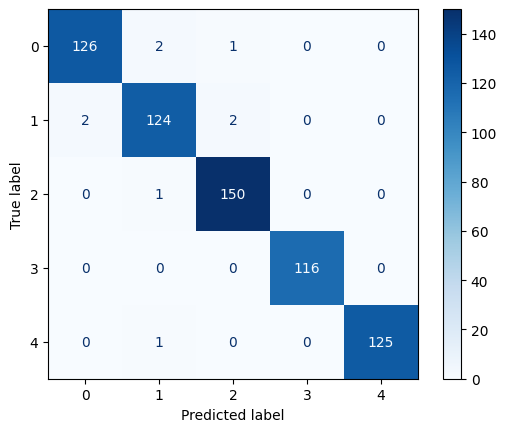

In [ ]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_features, y_train)
y_pred_rf = rf.predict(X_val_features)

In [ ]:
# Evaluate the model
accuracy_rf = accuracy_score(y_val, y_pred_rf)
print(f"Accuracy: {accuracy_rf * 100:.4f}%")
precision_rf, recall_rf, fscore_rf, average_rf = precision_recall_fscore_support(y_val, y_pred_rf, average='weighted')
print(f"Precission: {precision_rf * 100:.4f}%")
print(f"Recall: {recall_rf * 100:.4f}%")
print(f"F1: {fscore_rf * 100:.4f}%")

Accuracy: 100.0000%
Precission: 100.0000%
Recall: 100.0000%
F1: 100.0000%


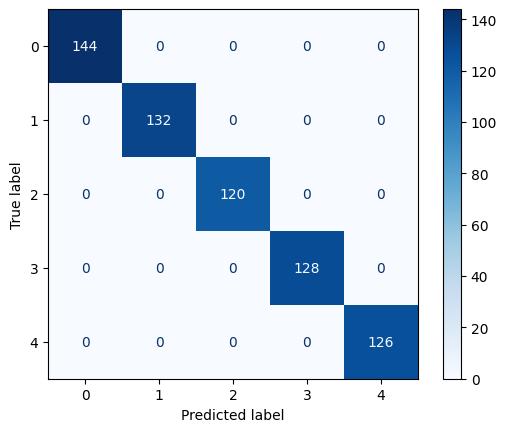

In [ ]:
cm = confusion_matrix(y_val, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
prediction_rf = rf.predict(x_test_normal)